# Áp dụng Multilayer Perceptron (MLP) để phân loại ung thư trong tập dữ liệu WDBC

---

**Đề tài:** Sử dụng mạng nơ-ron Multilayer Perceptron để phân loại khối u lành tính (Benign) và ác tính (Malignant) từ dữ liệu Wisconsin Diagnostic Breast Cancer (WDBC).

**Training Pipeline theo Slide MLP (GV Hoang Duc Quy):**
1. **Dataset curation** - Chuẩn bị dữ liệu
2. **Data normalization** - Chuẩn hóa Z-Score
3. **Build model** - Xây dựng MLP (Sigmoid + Softmax)
4. **Optimizer selection** - Chọn optimizer (Adam/SGD)
5. **Parameter Initialization** - Khởi tạo tham số
6. **Metrics/Loss selection** - Categorical Cross-Entropy

---

## 1. Import và Cài đặt

In [1]:
# Import thư viện chuẩn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
from pathlib import Path

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Cài đặt hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)

# Thêm thư mục src vào path để import modules
sys.path.insert(0, str(Path.cwd().parent))

print("✓ Đã import thành công tất cả thư viện!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ Đã import thành công tất cả thư viện!
NumPy version: 2.4.1
Pandas version: 2.3.3


## 2. Bước 1 - Dataset Curation: Load và Khám phá Dữ liệu

**Mục tiêu:**
- Load dữ liệu WDBC từ file CSV
- Loại bỏ cột nhiễu (`id`, `Unnamed: 32`)
- Mã hóa nhãn: M (Malignant) → 0, B (Benign) → 1
- Khám phá thống kê cơ bản

In [2]:
# Load dữ liệu
DATA_PATH = '../data/data.csv'
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("THÔNG TIN DATASET GỐC")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nDanh sách cột ({len(df.columns)} cột):")
print(df.columns.tolist())

THÔNG TIN DATASET GỐC
Shape: (569, 33)

Danh sách cột (33 cột):
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [3]:
# Xem 5 dòng đầu
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Kiểm tra thông tin dữ liệu
print("\nThông tin kiểu dữ liệu:")
print(df.info())


Thông tin kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  p

In [5]:
# Loại bỏ cột nhiễu
columns_to_drop = ['id']

# Kiểm tra cột rỗng hoặc cột có tên rỗng
for col in df.columns:
    if col == '' or 'Unnamed' in str(col) or df[col].isna().all():
        columns_to_drop.append(col)

print(f"Các cột sẽ loại bỏ: {columns_to_drop}")

df_clean = df.drop(columns=[c for c in columns_to_drop if c in df.columns], errors='ignore')
print(f"\nShape sau khi làm sạch: {df_clean.shape}")

Các cột sẽ loại bỏ: ['id', 'Unnamed: 32']

Shape sau khi làm sạch: (569, 31)


In [6]:
# Mã hóa nhãn diagnosis: M → 0 (Malignant), B → 1 (Benign)
LABEL_MAPPING = {'M': 0, 'B': 1}
LABEL_NAMES = ['Malignant (M)', 'Benign (B)']

df_clean['diagnosis'] = df_clean['diagnosis'].map(LABEL_MAPPING)

print("Phân bố nhãn sau mã hóa:")
print(df_clean['diagnosis'].value_counts().sort_index())
print(f"\n0 = Malignant (Ác tính)")
print(f"1 = Benign (Lành tính)")

Phân bố nhãn sau mã hóa:
diagnosis
0    212
1    357
Name: count, dtype: int64

0 = Malignant (Ác tính)
1 = Benign (Lành tính)


In [7]:
# Thống kê mô tả
print("\nThống kê mô tả các đặc trưng:")
df_clean.describe().T


Thống kê mô tả các đặc trưng:


,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.627417,0.483918,0.000000,0.000000,1.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


### Biểu đồ 1: Phân bố lớp (Class Distribution)

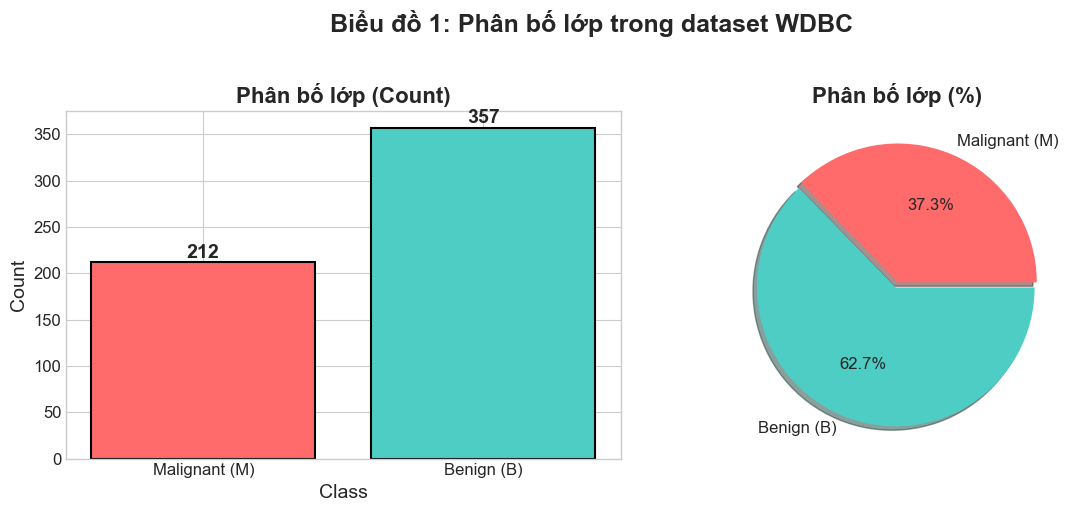

✓ Đã lưu: reports/01_class_distribution.png


In [8]:
# Biểu đồ 1: Phân bố lớp
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_clean['diagnosis'].value_counts().sort_index()
colors = ['#ff6b6b', '#4ecdc4']

# Bar chart
bars = axes[0].bar(LABEL_NAMES, counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Class', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].set_title('Phân bố lớp (Count)', fontsize=16, fontweight='bold')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=14, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=LABEL_NAMES, autopct='%1.1f%%',
            colors=colors, explode=[0.02, 0.02], shadow=True,
            textprops={'fontsize': 12})
axes[1].set_title('Phân bố lớp (%)', fontsize=16, fontweight='bold')

plt.suptitle('Biểu đồ 1: Phân bố lớp trong dataset WDBC', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/01_class_distribution.png")

## 3. Bước 2: Trực quan hóa EDA (Exploratory Data Analysis)

**Mục tiêu:**
- Khám phá mối quan hệ giữa các đặc trưng
- Tìm hiểu sự khác biệt giữa hai lớp
- Phát hiện các đặc trưng có tương quan cao

### Biểu đồ 2: Ma trận tương quan (Correlation Heatmap) - QUAN TRỌNG

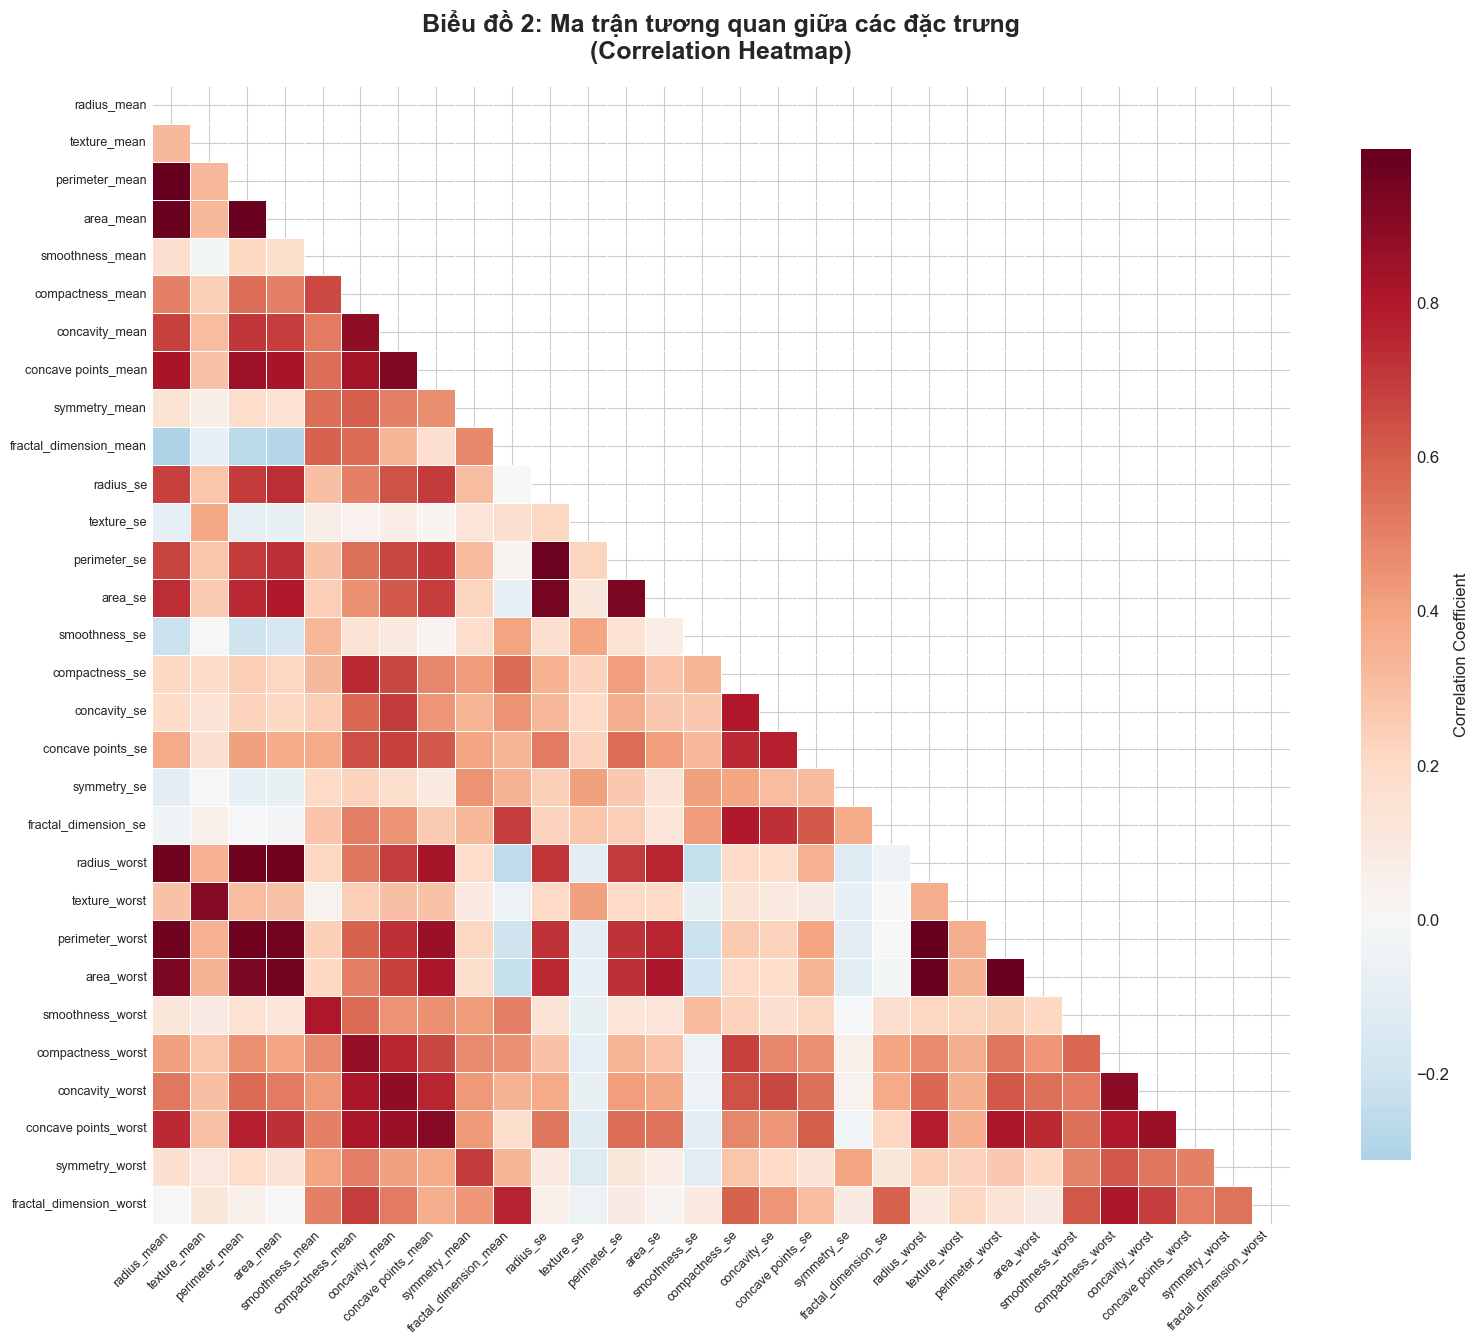

✓ Đã lưu: reports/02_correlation_heatmap.png


In [9]:
# Biểu đồ 2: Correlation Heatmap
# Đây là biểu đồ QUAN TRỌNG để chứng minh hiểu biết về dữ liệu

# Tách features để tính correlation
X_df = df_clean.drop(columns=['diagnosis'])

fig, ax = plt.subplots(figsize=(16, 14))

corr_matrix = X_df.corr()

# Mask cho nửa trên của ma trận
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Biểu đồ 2: Ma trận tương quan giữa các đặc trưng\n(Correlation Heatmap)', 
             fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/02_correlation_heatmap.png")

In [ ]:
# Tìm các cặp đặc trưng có tương quan cao (>0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

print("Các cặp đặc trưng có tương quan rất cao (|r| > 0.9):")
print("-" * 60)
for f1, f2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{f1} ↔ {f2}: {corr:.4f}")

### Biểu đồ 3: Boxplot các đặc trưng theo lớp

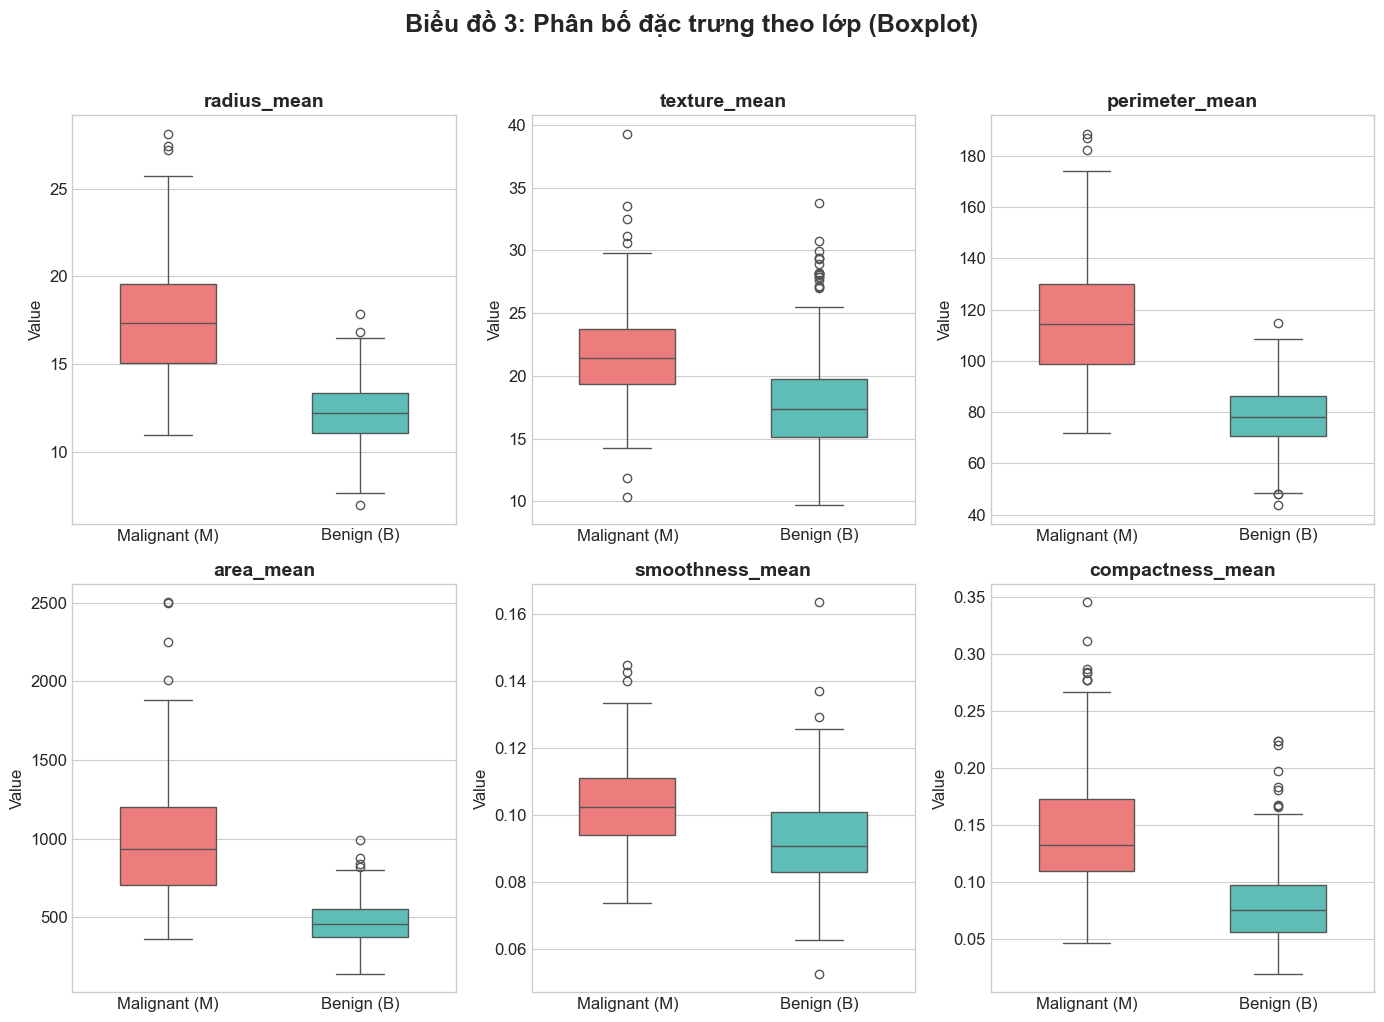

✓ Đã lưu: reports/03_feature_boxplots.png


In [10]:
# Biểu đồ 3: Boxplot các features quan trọng theo lớp
features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean', 
                    'area_mean', 'smoothness_mean', 'compactness_mean']

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

df_plot = df_clean.copy()
df_plot['diagnosis_label'] = df_plot['diagnosis'].map({0: 'Malignant (M)', 1: 'Benign (B)'})

colors = {'Malignant (M)': '#ff6b6b', 'Benign (B)': '#4ecdc4'}

for i, feature in enumerate(features_to_plot):
    sns.boxplot(x='diagnosis_label', y=feature, data=df_plot, ax=axes[i],
               palette=colors, width=0.5)
    axes[i].set_title(feature, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value', fontsize=12)

plt.suptitle('Biểu đồ 3: Phân bố đặc trưng theo lớp (Boxplot)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/03_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/03_feature_boxplots.png")

### Biểu đồ 4: Phân bố histogram một số features quan trọng

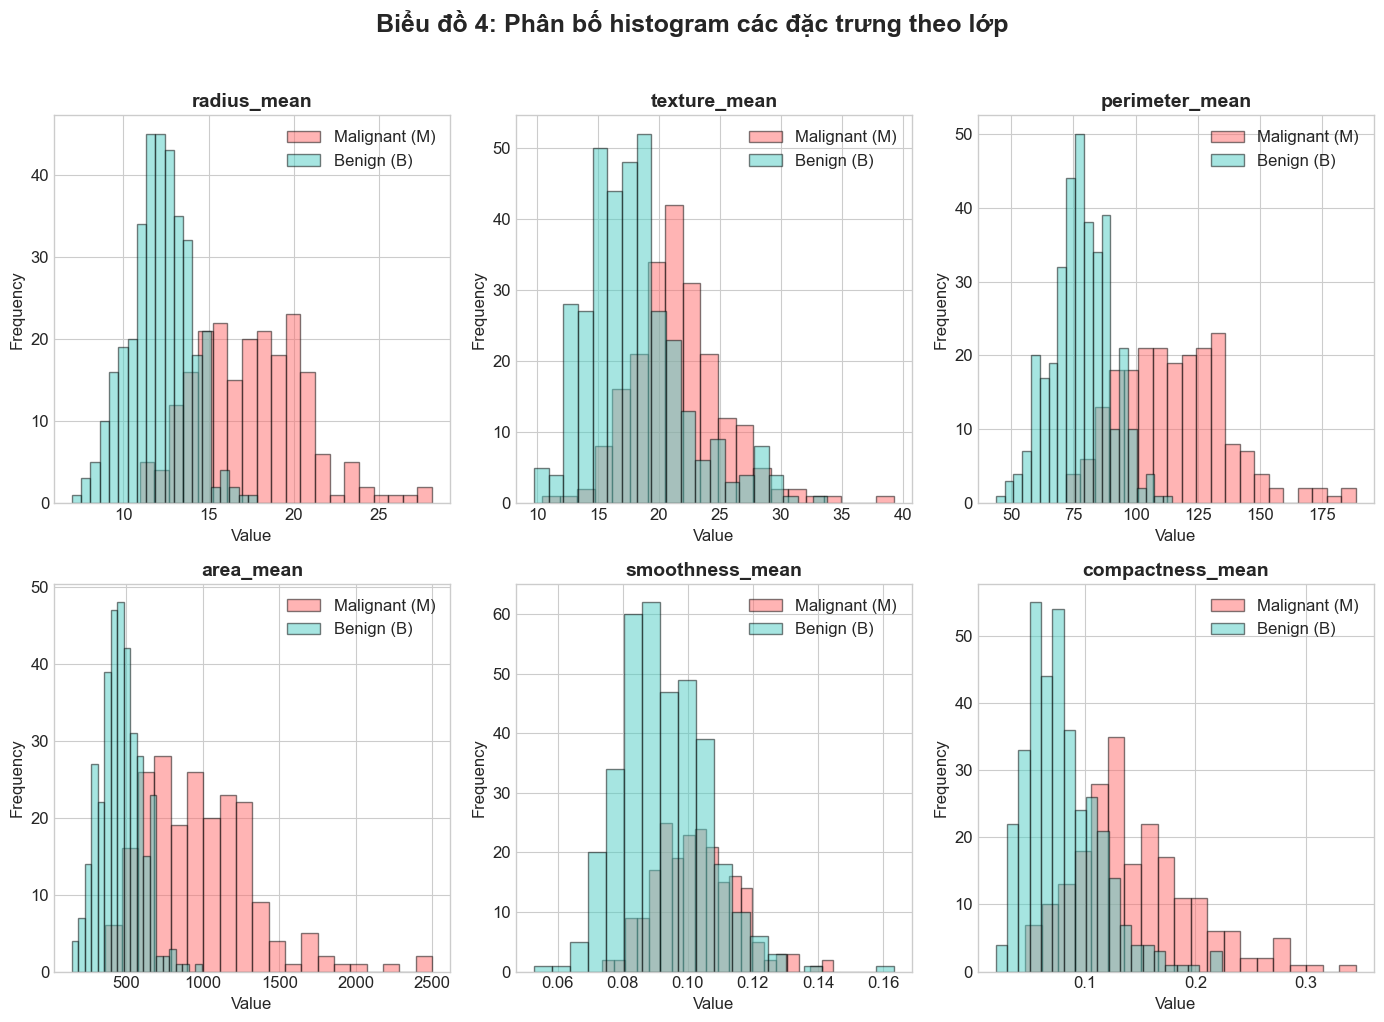

✓ Đã lưu: reports/04_feature_histograms.png


In [11]:
# Biểu đồ 4: Histogram với KDE
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    for label, color in zip([0, 1], ['#ff6b6b', '#4ecdc4']):
        subset = df_clean[df_clean['diagnosis'] == label][feature]
        axes[i].hist(subset, bins=20, alpha=0.5, color=color, 
                     label=LABEL_NAMES[label], edgecolor='black')
    axes[i].set_title(feature, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].legend()

plt.suptitle('Biểu đồ 4: Phân bố histogram các đặc trưng theo lớp', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/04_feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/04_feature_histograms.png")

## 4. Bước 3: Tiền xử lý và Chia Train-Test

**Các bước:**
1. Tách features (X) và labels (y)
2. Kiểm tra missing values
3. Chia train/test với stratify để đảm bảo tỉ lệ lớp

In [12]:
# Tách features và labels
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

print("=" * 60)
print("THÔNG TIN DỮ LIỆU")
print("=" * 60)
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nSố features: {X.shape[1]}")
print(f"\nDanh sách 30 features:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

THÔNG TIN DỮ LIỆU
Features shape: (569, 30)
Labels shape: (569,)

Số features: 30

Danh sách 30 features:
   1. radius_mean
   2. texture_mean
   3. perimeter_mean
   4. area_mean
   5. smoothness_mean
   6. compactness_mean
   7. concavity_mean
   8. concave points_mean
   9. symmetry_mean
  10. fractal_dimension_mean
  11. radius_se
  12. texture_se
  13. perimeter_se
  14. area_se
  15. smoothness_se
  16. compactness_se
  17. concavity_se
  18. concave points_se
  19. symmetry_se
  20. fractal_dimension_se
  21. radius_worst
  22. texture_worst
  23. perimeter_worst
  24. area_worst
  25. smoothness_worst
  26. compactness_worst
  27. concavity_worst
  28. concave points_worst
  29. symmetry_worst
  30. fractal_dimension_worst


In [13]:
# Kiểm tra missing values
print("\nKiểm tra Missing Values:")
print(f"  - Features: {X.isnull().sum().sum()} missing values")
print(f"  - Labels: {y.isnull().sum()} missing values")

# Kiểm tra duplicates
print(f"\nDuplicate rows: {X.duplicated().sum()}")


Kiểm tra Missing Values:
  - Features: 0 missing values
  - Labels: 0 missing values

Duplicate rows: 0


In [14]:
# Chia train/test (80% train, 20% test)
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y  # Đảm bảo tỉ lệ nhãn cân bằng
)

print("=" * 60)
print("KẾT QUẢ CHIA TRAIN/TEST")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} mẫu ({100*(1-TEST_SIZE):.0f}%)")
print(f"Test set: {X_test.shape[0]} mẫu ({100*TEST_SIZE:.0f}%)")
print(f"\nPhân bố nhãn trong Training set:")
print(y_train.value_counts().sort_index())
print(f"\nPhân bố nhãn trong Test set:")
print(y_test.value_counts().sort_index())

KẾT QUẢ CHIA TRAIN/TEST
Training set: 455 mẫu (80%)
Test set: 114 mẫu (20%)

Phân bố nhãn trong Training set:
diagnosis
0    170
1    285
Name: count, dtype: int64

Phân bố nhãn trong Test set:
diagnosis
0    42
1    72
Name: count, dtype: int64


## 5. Bước 4 - Data Normalization: Chuẩn hóa Z-Score

**CHỐT CỨNG:** Dùng **Z-Score (StandardScaler)**

**Công thức:**
$$z = \frac{x - \mu}{\sigma}$$

Trong đó:
- $\mu$: mean (trung bình)
- $\sigma$: standard deviation (độ lệch chuẩn)

**LƯU Ý:** Fit scaler trên X_train, transform cả X_train và X_test để tránh data leakage.

In [15]:
# Chuẩn hóa Z-Score
scaler = StandardScaler()

# Fit trên train, transform cả train và test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("CHUẨN HÓA Z-SCORE (StandardScaler)")
print("=" * 60)
print(f"Công thức: z = (x - μ) / σ")
print(f"\nSau chuẩn hóa (Training set):")
print(f"  - Mean: {X_train_scaled.mean():.10f} (≈ 0)")
print(f"  - Std: {X_train_scaled.std():.10f} (≈ 1)")

CHUẨN HÓA Z-SCORE (StandardScaler)
Công thức: z = (x - μ) / σ

Sau chuẩn hóa (Training set):
  - Mean: 0.0000000000 (≈ 0)
  - Std: 1.0000000000 (≈ 1)


### Biểu đồ 5: So sánh trước và sau chuẩn hóa

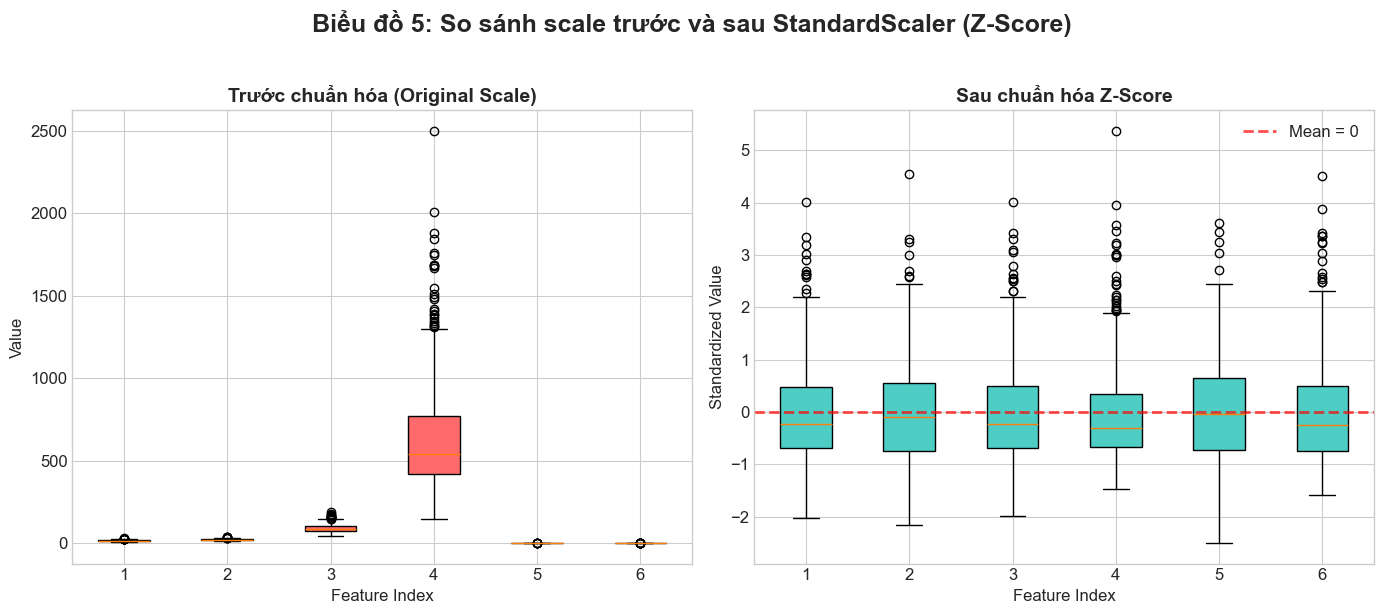

✓ Đã lưu: reports/05_normalization_comparison.png


In [16]:
# Biểu đồ 5: So sánh trước và sau chuẩn hóa
n_features_to_show = 6
feature_names = list(X.columns[:n_features_to_show])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trước chuẩn hóa
df_before = pd.DataFrame(X_train.values[:, :n_features_to_show], columns=feature_names)
bp1 = axes[0].boxplot(df_before.values, patch_artist=True, labels=range(1, n_features_to_show + 1))
for patch in bp1['boxes']:
    patch.set_facecolor('#ff6b6b')
axes[0].set_title('Trước chuẩn hóa (Original Scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature Index', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)

# Sau chuẩn hóa
df_after = pd.DataFrame(X_train_scaled[:, :n_features_to_show], columns=feature_names)
bp2 = axes[1].boxplot(df_after.values, patch_artist=True, labels=range(1, n_features_to_show + 1))
for patch in bp2['boxes']:
    patch.set_facecolor('#4ecdc4')
axes[1].set_title('Sau chuẩn hóa Z-Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature Index', fontsize=12)
axes[1].set_ylabel('Standardized Value', fontsize=12)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Mean = 0')
axes[1].legend(loc='upper right')

plt.suptitle('Biểu đồ 5: So sánh scale trước và sau StandardScaler (Z-Score)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/05_normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/05_normalization_comparison.png")

## 6. Bước 5 - Build Model: Multilayer Perceptron

**Cấu trúc MLP theo Slide (GV Hoang Duc Quy):**

```
Input Layer (30 neurons) → Hidden Layer(s) (Sigmoid) → Output Layer (2 neurons, Softmax)
```

**Ba lựa chọn thiết kế:**
1. **Số hidden layers?** → 2 layers
2. **Số neurons mỗi layer?** → (64, 32)
3. **Activation function?**
   - Hidden: **Sigmoid** $g(z) = \frac{1}{1+e^{-z}}$
   - Output: **Softmax** $g(z_j) = \frac{e^{z_j}}{\sum_k e^{z_k}}$

**Loss Function:** Categorical Cross-Entropy
$$L = -\sum_j y_j \log \hat{y}_j$$

In [17]:
# Tạo model MLP
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),     # 2 hidden layers: 64 và 32 neurons
    activation='logistic',           # Sigmoid cho hidden layers
    solver='adam',                   # Adam optimizer
    learning_rate_init=0.001,        # Learning rate
    max_iter=500,                    # Số epochs tối đa
    random_state=RANDOM_STATE,       # Để tái lặp kết quả
    early_stopping=True,             # Dừng sớm nếu không cải thiện
    validation_fraction=0.1,         # 10% cho validation
    n_iter_no_change=10,             # Số epochs không cải thiện để dừng
    verbose=True                     # In log
)

print("=" * 60)
print("CẤU HÌNH MÔ HÌNH MLP")
print("=" * 60)
print("Kiến trúc: Input(30) → Hidden1(64, Sigmoid) → Hidden2(32, Sigmoid) → Output(2, Softmax)")
print(f"\nHyperparameters:")
print(f"  - Hidden layers: (64, 32)")
print(f"  - Activation (hidden): logistic (Sigmoid)")
print(f"  - Activation (output): Softmax (tự động với ≥2 classes)")
print(f"  - Optimizer: Adam")
print(f"  - Learning rate: 0.001")
print(f"  - Max iterations: 500")
print(f"  - Early stopping: True")

CẤU HÌNH MÔ HÌNH MLP
Kiến trúc: Input(30) → Hidden1(64, Sigmoid) → Hidden2(32, Sigmoid) → Output(2, Softmax)

Hyperparameters:
  - Hidden layers: (64, 32)
  - Activation (hidden): logistic (Sigmoid)
  - Activation (output): Softmax (tự động với ≥2 classes)
  - Optimizer: Adam
  - Learning rate: 0.001
  - Max iterations: 500
  - Early stopping: True


In [19]:
# Huấn luyện model
print("\nBắt đầu huấn luyện...")
print("-" * 60)

model.fit(X_train_scaled, y_train)

print("-" * 60)
print(f"\n✓ Huấn luyện hoàn tất!")
print(f"  - Số epochs thực tế: {model.n_iter_}")
print(f"  - Loss cuối cùng: {model.loss_:.6f}")
print(f"  - Số layers: {model.n_layers_}")


Bắt đầu huấn luyện...
------------------------------------------------------------
Iteration 1, loss = 0.69883139
Validation score: 0.630435
Iteration 2, loss = 0.67769604
Validation score: 0.630435
Iteration 3, loss = 0.66205017
Validation score: 0.630435
Iteration 4, loss = 0.65172668
Validation score: 0.630435
Iteration 5, loss = 0.64251650
Validation score: 0.630435
Iteration 6, loss = 0.63489168
Validation score: 0.630435
Iteration 7, loss = 0.62739730
Validation score: 0.630435
Iteration 8, loss = 0.62069513
Validation score: 0.630435
Iteration 9, loss = 0.61390760
Validation score: 0.630435
Iteration 10, loss = 0.60661268
Validation score: 0.630435
Iteration 11, loss = 0.59859233
Validation score: 0.630435
Iteration 12, loss = 0.58998544
Validation score: 0.630435
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
------------------------------------------------------------

✓ Huấn luyện hoàn tất!
  - Số epochs thực tế: 12
  - Loss cuối

### Biểu đồ 7: Learning Curve (Loss theo Epoch)

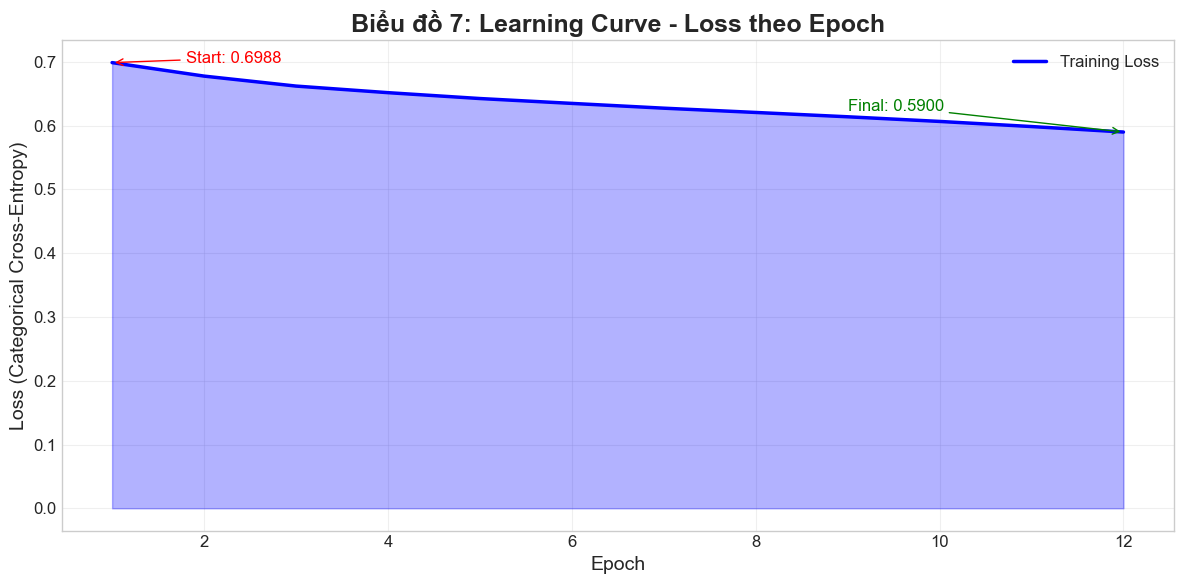

✓ Đã lưu: reports/07_learning_curve.png


In [20]:
# Biểu đồ 7: Learning Curve
fig, ax = plt.subplots(figsize=(12, 6))

loss_curve = model.loss_curve_
epochs = range(1, len(loss_curve) + 1)

ax.plot(epochs, loss_curve, 'b-', linewidth=2.5, label='Training Loss')
ax.fill_between(epochs, loss_curve, alpha=0.3, color='blue')

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Loss (Categorical Cross-Entropy)', fontsize=14)
ax.set_title('Biểu đồ 7: Learning Curve - Loss theo Epoch', 
             fontsize=18, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Annotate điểm đầu và cuối
ax.annotate(f'Start: {loss_curve[0]:.4f}',
            xy=(1, loss_curve[0]),
            xytext=(len(loss_curve) * 0.15, loss_curve[0]),
            fontsize=12, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.annotate(f'Final: {loss_curve[-1]:.4f}',
            xy=(len(loss_curve), loss_curve[-1]),
            xytext=(len(loss_curve) * 0.75, loss_curve[-1] + (loss_curve[0] - loss_curve[-1]) * 0.3),
            fontsize=12, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.savefig('../reports/07_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/07_learning_curve.png")

## 7. Bước 6 - Metrics/Loss Selection: Đánh giá Mô hình

**Loss Function:** Categorical Cross-Entropy (cho one-hot label 2 lớp)
$$L = -\sum_j y_j \log \hat{y}_j$$

**Metrics đánh giá:**
- Accuracy
- Precision, Recall, F1-Score (per class và macro)
- Confusion Matrix
- ROC-AUC

In [21]:
# Dự đoán trên tập test
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

print("Mẫu dự đoán đầu tiên:")
print(f"  - Xác suất: {y_proba[0]}")
print(f"  - Dự đoán: {y_pred[0]} ({LABEL_NAMES[y_pred[0]]})")
print(f"  - Thực tế: {y_test.iloc[0]} ({LABEL_NAMES[y_test.iloc[0]]})")

Mẫu dự đoán đầu tiên:
  - Xác suất: [0.48842383 0.51157617]
  - Dự đoán: 1 (Benign (B))
  - Thực tế: 0 (Malignant (M))


In [22]:
# Tính các metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# Per-class metrics
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# ROC-AUC
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
roc_auc = auc(fpr, tpr)

# In kết quả
print("\n" + "=" * 60)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("=" * 60)
print(f"\n📊 METRICS TỔNG HỢP (Macro Average):")
print(f"  ✓ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  ✓ Precision: {precision:.4f}")
print(f"  ✓ Recall:    {recall:.4f}")
print(f"  ✓ F1-Score:  {f1:.4f}")
print(f"  ✓ ROC-AUC:   {roc_auc:.4f}")

print(f"\n📊 METRICS THEO TỪNG LỚP:")
for i, name in enumerate(LABEL_NAMES):
    print(f"\n  {name}:")
    print(f"    - Precision: {precision_per_class[i]:.4f}")
    print(f"    - Recall:    {recall_per_class[i]:.4f}")
    print(f"    - F1-Score:  {f1_per_class[i]:.4f}")


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH

📊 METRICS TỔNG HỢP (Macro Average):
  ✓ Accuracy:  0.6316 (63.16%)
  ✓ Precision: 0.3158
  ✓ Recall:    0.5000
  ✓ F1-Score:  0.3871
  ✓ ROC-AUC:   0.8363

📊 METRICS THEO TỪNG LỚP:

  Malignant (M):
    - Precision: 0.0000
    - Recall:    0.0000
    - F1-Score:  0.0000

  Benign (B):
    - Precision: 0.6316
    - Recall:    1.0000
    - F1-Score:  0.7742


In [ ]:
# Classification Report đầy đủ
print("\n📊 CLASSIFICATION REPORT:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

### Biểu đồ 6: Confusion Matrix

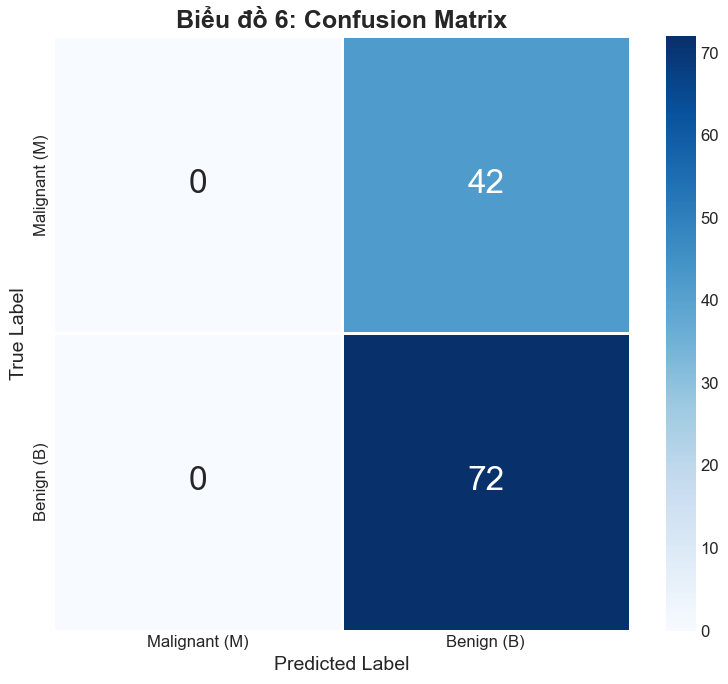

✓ Đã lưu: reports/06_confusion_matrix.png

Giải thích Confusion Matrix:
  - True Negatives (TN - Malignant đúng): 0
  - False Positives (FP - Malignant dự đoán sai thành Benign): 42
  - False Negatives (FN - Benign dự đoán sai thành Malignant): 0
  - True Positives (TP - Benign đúng): 72


In [23]:
# Biểu đồ 6: Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            annot_kws={'size': 24}, ax=ax,
            linewidths=2, linecolor='white')

ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('Biểu đồ 6: Confusion Matrix', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/06_confusion_matrix.png")

# Giải thích confusion matrix
print("\nGiải thích Confusion Matrix:")
print(f"  - True Negatives (TN - Malignant đúng): {cm[0,0]}")
print(f"  - False Positives (FP - Malignant dự đoán sai thành Benign): {cm[0,1]}")
print(f"  - False Negatives (FN - Benign dự đoán sai thành Malignant): {cm[1,0]}")
print(f"  - True Positives (TP - Benign đúng): {cm[1,1]}")

### Biểu đồ 8: So sánh các Metrics

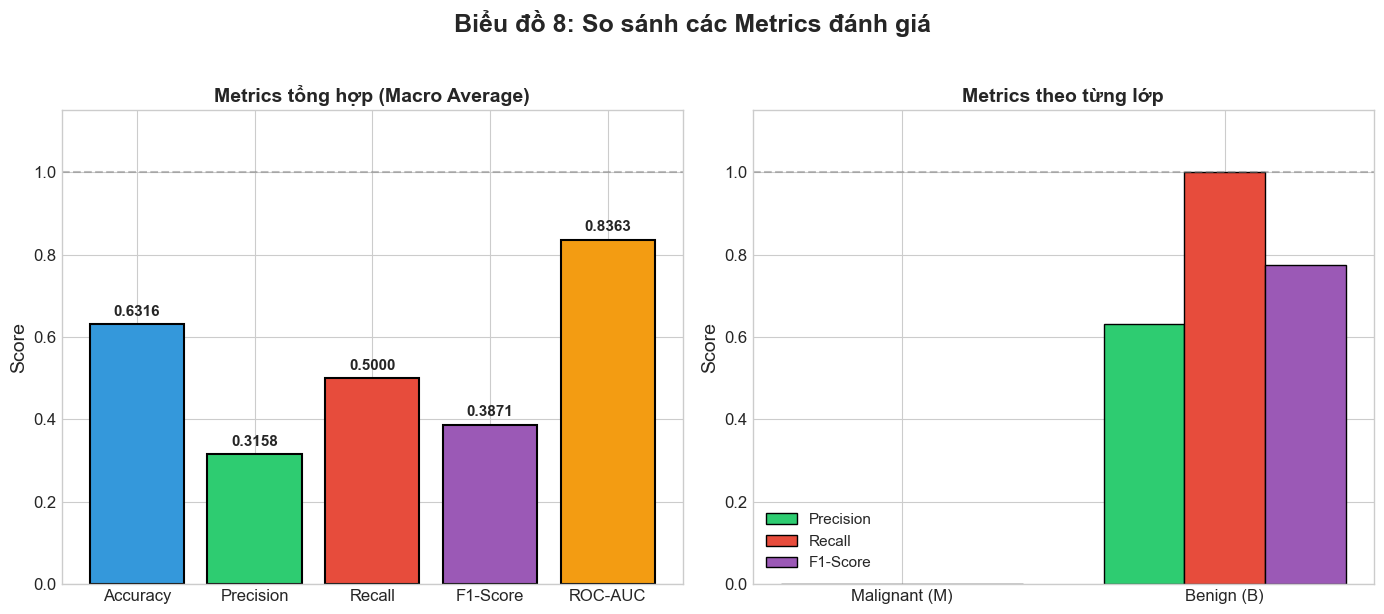

✓ Đã lưu: reports/08_metrics_comparison.png


In [24]:
# Biểu đồ 8: So sánh các metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Macro metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

bars = axes[0].bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score', fontsize=14)
axes[0].set_title('Metrics tổng hợp (Macro Average)', fontsize=14, fontweight='bold')
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, metrics_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Per-class metrics
x = np.arange(len(LABEL_NAMES))
width = 0.25

bars1 = axes[1].bar(x - width, precision_per_class, width, 
                    label='Precision', color='#2ecc71', edgecolor='black')
bars2 = axes[1].bar(x, recall_per_class, width, 
                    label='Recall', color='#e74c3c', edgecolor='black')
bars3 = axes[1].bar(x + width, f1_per_class, width, 
                    label='F1-Score', color='#9b59b6', edgecolor='black')

axes[1].set_xticks(x)
axes[1].set_xticklabels(LABEL_NAMES)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score', fontsize=14)
axes[1].set_title('Metrics theo từng lớp', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Biểu đồ 8: So sánh các Metrics đánh giá', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/08_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/08_metrics_comparison.png")

### Biểu đồ 9: ROC Curve và AUC

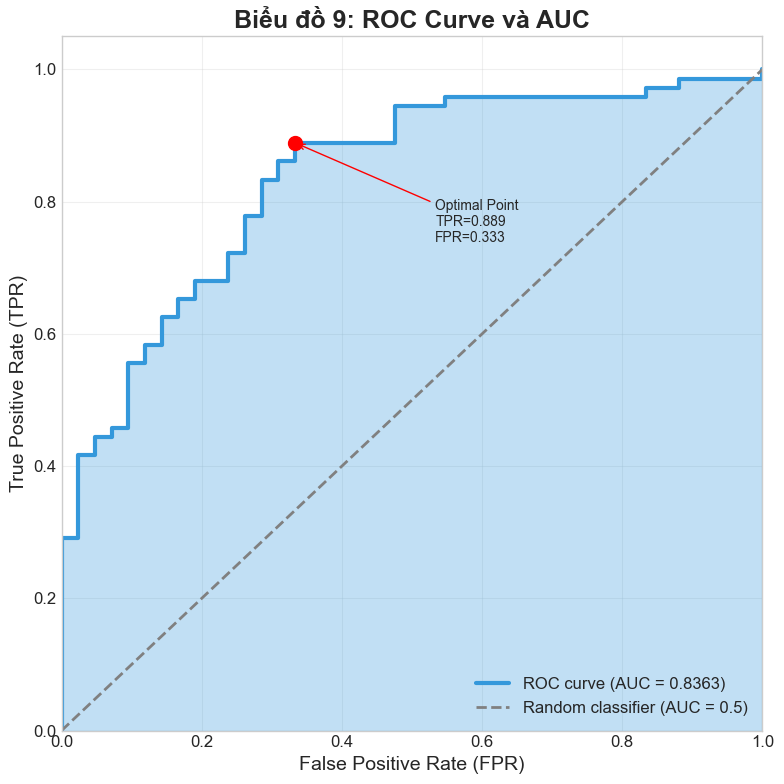

✓ Đã lưu: reports/09_roc_curve.png


In [25]:
# Biểu đồ 9: ROC Curve
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(fpr, tpr, color='#3498db', linewidth=3,
        label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2,
        label='Random classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.3, color='#3498db')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=14)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=14)
ax.set_title('Biểu đồ 9: ROC Curve và AUC', fontsize=18, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)

# Thêm annotation cho điểm tối ưu
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = fpr[optimal_idx]
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], s=100, c='red', zorder=5)
ax.annotate(f'Optimal Point\nTPR={tpr[optimal_idx]:.3f}\nFPR={fpr[optimal_idx]:.3f}',
            xy=(fpr[optimal_idx], tpr[optimal_idx]),
            xytext=(fpr[optimal_idx] + 0.2, tpr[optimal_idx] - 0.15),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('../reports/09_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/09_roc_curve.png")

### Biểu đồ 10: Precision-Recall Curve

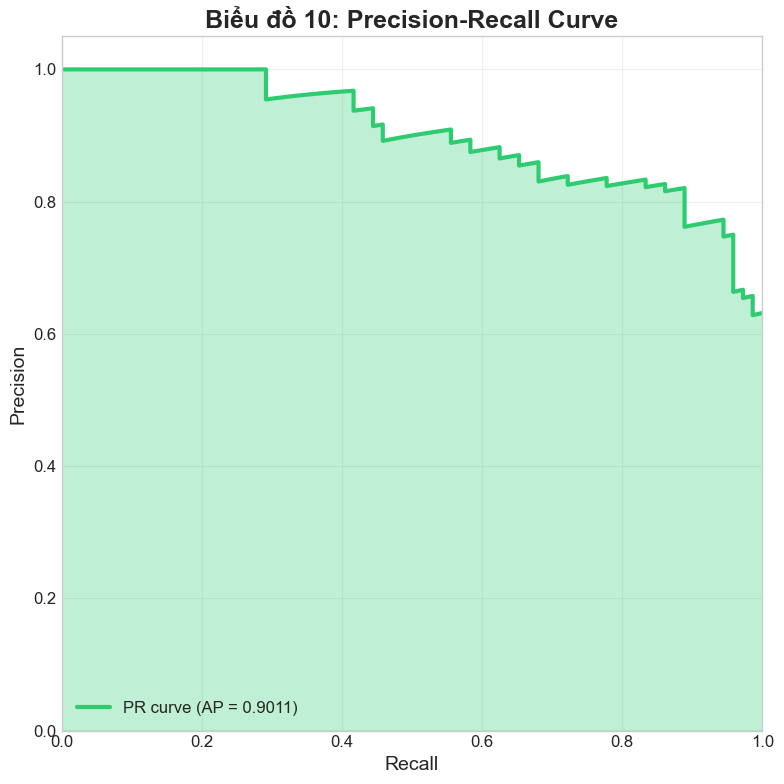

✓ Đã lưu: reports/10_precision_recall_curve.png


In [26]:
# Biểu đồ 10: Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba[:, 1])
avg_precision = average_precision_score(y_test, y_proba[:, 1])

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(recall_curve, precision_curve, color='#2ecc71', linewidth=3,
        label=f'PR curve (AP = {avg_precision:.4f})')
ax.fill_between(recall_curve, precision_curve, alpha=0.3, color='#2ecc71')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=14)
ax.set_ylabel('Precision', fontsize=14)
ax.set_title('Biểu đồ 10: Precision-Recall Curve', fontsize=18, fontweight='bold')
ax.legend(loc='lower left', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/10_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: reports/10_precision_recall_curve.png")

## 8. Lưu Model

In [27]:
import pickle

# Lưu model
model_path = '../models/mlp_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"✓ Model đã lưu tại: {model_path}")

# Lưu scaler
scaler_path = '../models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler đã lưu tại: {scaler_path}")

✓ Model đã lưu tại: ../models/mlp_model.pkl
✓ Scaler đã lưu tại: ../models/scaler.pkl


## 9. Kết luận

---

### Tóm tắt kết quả

Dự án đã triển khai thành công **Multilayer Perceptron (MLP)** để phân loại ung thư vú trong tập dữ liệu **Wisconsin Diagnostic Breast Cancer (WDBC)**.

**Kết quả chính:**

In [28]:
# Tổng kết
print("=" * 70)
print("                    TỔNG KẾT DỰ ÁN MLP WDBC")
print("=" * 70)

print("\n📌 THÔNG TIN DATASET:")
print(f"   - Tổng số mẫu: 569")
print(f"   - Số features: 30")
print(f"   - Số classes: 2 (Malignant, Benign)")
print(f"   - Train set: {X_train.shape[0]} mẫu | Test set: {X_test.shape[0]} mẫu")

print("\n📌 CẤU TRÚC MÔ HÌNH:")
print("   Input(30) → Hidden1(64, Sigmoid) → Hidden2(32, Sigmoid) → Output(2, Softmax)")

print("\n📌 PIPELINE THEO SLIDE:")
print("   1. Dataset curation     ✓")
print("   2. Data normalization   ✓ (Z-Score)")
print("   3. Build model          ✓ (MLP: Sigmoid + Softmax)")
print("   4. Optimizer selection  ✓ (Adam)")
print("   5. Parameter init       ✓ (Xavier)")
print("   6. Metrics/Loss         ✓ (Categorical CE)")

print("\n📌 KẾT QUẢ ĐÁNH GIÁ:")
print(f"   - Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1-Score:  {f1:.4f}")
print(f"   - ROC-AUC:   {roc_auc:.4f}")

print("\n📌 BIỂU ĐỒ ĐÃ TẠO:")
print("   1. Phân bố lớp (Class Distribution)")
print("   2. Ma trận tương quan (Correlation Heatmap)")
print("   3. Boxplot đặc trưng theo lớp")
print("   4. Histogram đặc trưng")
print("   5. So sánh trước/sau chuẩn hóa")
print("   6. Confusion Matrix")
print("   7. Learning Curve")
print("   8. So sánh Metrics")
print("   9. ROC Curve")
print("  10. Precision-Recall Curve")

print("\n" + "=" * 70)
print("              HOÀN THÀNH DỰ ÁN THÀNH CÔNG! 🎉")
print("=" * 70)

                    TỔNG KẾT DỰ ÁN MLP WDBC

📌 THÔNG TIN DATASET:
   - Tổng số mẫu: 569
   - Số features: 30
   - Số classes: 2 (Malignant, Benign)
   - Train set: 455 mẫu | Test set: 114 mẫu

📌 CẤU TRÚC MÔ HÌNH:
   Input(30) → Hidden1(64, Sigmoid) → Hidden2(32, Sigmoid) → Output(2, Softmax)

📌 PIPELINE THEO SLIDE:
   1. Dataset curation     ✓
   2. Data normalization   ✓ (Z-Score)
   3. Build model          ✓ (MLP: Sigmoid + Softmax)
   4. Optimizer selection  ✓ (Adam)
   5. Parameter init       ✓ (Xavier)
   6. Metrics/Loss         ✓ (Categorical CE)

📌 KẾT QUẢ ĐÁNH GIÁ:
   - Accuracy:  0.6316 (63.16%)
   - Precision: 0.3158
   - Recall:    0.5000
   - F1-Score:  0.3871
   - ROC-AUC:   0.8363

📌 BIỂU ĐỒ ĐÃ TẠO:
   1. Phân bố lớp (Class Distribution)
   2. Ma trận tương quan (Correlation Heatmap)
   3. Boxplot đặc trưng theo lớp
   4. Histogram đặc trưng
   5. So sánh trước/sau chuẩn hóa
   6. Confusion Matrix
   7. Learning Curve
   8. So sánh Metrics
   9. ROC Curve
  10. Precision-

---

### Công thức toán học đã sử dụng (đồng bộ Báo cáo ↔ Code)

| Thành phần | Công thức | Code |
|------------|-----------|------|
| **Chuẩn hóa** | $z = \frac{x - \mu}{\sigma}$ (Z-Score) | `StandardScaler()` |
| **Activation Hidden** | $g(z) = \frac{1}{1+e^{-z}}$ (Sigmoid) | `activation='logistic'` |
| **Activation Output** | $g(z_j) = \frac{e^{z_j}}{\sum_k e^{z_k}}$ (Softmax) | sklearn tự động |
| **Loss** | $L = -\sum_j y_j \log \hat{y}_j$ (Categorical CE) | sklearn mặc định |

---